# Introdução

Esse notebook tem o objetivo de analisar o desempenho dos modelos forecasting, pesquisar e tentar entender padrões mais profundos dos dados.

# Código

In [16]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import glob
from itertools import product
import sys
import os
import seaborn as sns

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
app_path = os.path.abspath(os.path.join('..', 'app'))
if app_path not in sys.path:
    sys.path.append(app_path)

from app.database import SessionLocal
from sqlalchemy import text

In [24]:
def carregar_relatorios():
    arquivos = sorted(glob.glob("data/relatorio_*.csv"))
    dfs = []

    for arquivo in arquivos:
        nome_arquivo = os.path.basename(arquivo)
        data_str = (
            nome_arquivo
            .replace("relatorio_", "")
            .replace(".csv", "")
        )
        data_arquivo = pd.to_datetime(
            data_str,
            format="%d-%m-%Y"
        ).strftime("%Y-%m-%d")
        df = pd.read_csv(arquivo)
        df = df.reset_index()
        df = df.drop(columns=("Área1-Pessoas que entraram"))
        df.columns = ['timestamp', 'fluxo']
        df['hora_inicio'] = df['timestamp'].str.split('-').str[0]
        df['timestamp'] = pd.to_datetime(
            data_arquivo + ' ' + df['hora_inicio']
        )
        df.set_index('timestamp', inplace=True)
        df.drop(columns=['hora_inicio'], inplace=True)
        dfs.append(df)
    df_final = pd.concat(dfs)
    df_final = df_final.sort_index()
    df_final.index.freq = 'h'

    return df_final

db = SessionLocal()

map_lojas = {
    205709335: "Vans",
    205709338: "Arezzo",
    205785185: "Off Premium",
    206057004: "Ida",
    205613392: "Aramis",
    205406209: "High",
    206057013: "Vix",
    206057007: "Surto dos 50"
}

try:
    query = text("""
        SELECT id_loja, quantidade, timestamp
        FROM vendas_itens
        WHERE timestamp BETWEEN '2026-05-07 00:00:00'
        AND '2026-05-09 23:59:59'
    """)

    df = pd.read_sql_query(query, db.bind)

    df["loja"] = df["id_loja"].map(map_lojas)

    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.floor("h")

    # Agrupa
    df = (
        df.groupby(["loja", "timestamp"])["quantidade"]
        .sum()
        .reset_index()
    )

    # Range completo de horas
    full_range = pd.date_range(
        start="2026-05-07 00:00:00",
        end="2026-05-09 23:59:59",
        freq="h"
    )

    # Cria todas combinações loja x hora
    idx = pd.MultiIndex.from_product(
        [df["loja"].unique(), full_range],
        names=["loja", "timestamp"]
    )

    # Reindex correto
    df = (
        df.set_index(["loja", "timestamp"])
        .reindex(idx, fill_value=0)
        .reset_index()
    )

    df.rename(columns={"quantidade": "fluxo"}, inplace=True)

    df_vendas_real = df.sort_values(["loja", "timestamp"])

    print("Dados carregados com sucesso!")
    print(df_vendas_real.head())

except Exception as e:
    print(f"Erro ao carregar os dados: {e}")

finally:
    db.close()

df_fluxo_real = carregar_relatorios()
print(df_fluxo_real.head())

Dados carregados com sucesso!
     loja           timestamp  fluxo
0  Aramis 2026-05-07 00:00:00    0.0
1  Aramis 2026-05-07 01:00:00    0.0
2  Aramis 2026-05-07 02:00:00    0.0
3  Aramis 2026-05-07 03:00:00    0.0
4  Aramis 2026-05-07 04:00:00    0.0
                     fluxo
timestamp                 
2026-05-06 00:00:00      5
2026-05-06 01:00:00      0
2026-05-06 02:00:00      0
2026-05-06 03:00:00      0
2026-05-06 04:00:00      0


In [25]:
db = SessionLocal()

try:
    query = text("""
        SELECT loja, previsao, timestamp_previsao
        FROM previsoes_vendas
        WHERE timestamp_previsao BETWEEN '2026-05-07 00:00:00'
        AND '2026-05-09 23:59:59'
    """)

    df = pd.read_sql_query(query, db.bind)

    df["timestamp_previsao"] = pd.to_datetime(
        df["timestamp_previsao"]
    ).dt.floor("h")

    full_range = pd.date_range(
        start="2026-05-07 00:00:00",
        end="2026-05-09 23:00:00",
        freq="h"
    )

    lojas = df["loja"].unique()

    full_index = pd.MultiIndex.from_product(
        [lojas, full_range],
        names=["loja", "timestamp_previsao"]
    )

    df = (
        df.set_index(["loja", "timestamp_previsao"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    df_vendas_previsao = df[df["loja"] != "Fluxo"]
    df_fluxo_previsao = df[df["loja"] == "Fluxo"]

    print("Dados carregados com sucesso!")

except Exception as e:
    print(f"Erro ao carregar os dados: {e}")

finally:
    db.close()


print(df_vendas_previsao.head())
print(df_fluxo_previsao.head())

Dados carregados com sucesso!
     loja  timestamp_previsao   previsao
0  Aramis 2026-05-07 00:00:00   9.370745
1  Aramis 2026-05-07 01:00:00  13.973949
2  Aramis 2026-05-07 02:00:00   0.577248
3  Aramis 2026-05-07 03:00:00  10.180513
4  Aramis 2026-05-07 04:00:00   4.785202
      loja  timestamp_previsao   previsao
576  Fluxo 2026-05-07 00:00:00 -38.362146
577  Fluxo 2026-05-07 01:00:00  45.242184
578  Fluxo 2026-05-07 02:00:00  70.889905
579  Fluxo 2026-05-07 03:00:00  39.997878
580  Fluxo 2026-05-07 04:00:00  53.324984


In [26]:
df_fluxo_comparacao = df_fluxo_real.merge(
    df_fluxo_previsao,
    left_index=True,
    right_on="timestamp_previsao",
    how="inner"
)

df_fluxo_comparacao = df_fluxo_comparacao[(df_fluxo_comparacao['timestamp_previsao'].dt.hour >= 10) &
                                            (df_fluxo_comparacao['timestamp_previsao'].dt.hour <= 22)]

mae = np.mean(
    np.abs(df_fluxo_comparacao['fluxo'] - df_fluxo_comparacao['previsao'])
)

wape = (
    np.abs(df_fluxo_comparacao['fluxo'] - df_fluxo_comparacao['previsao']).sum()
    / df_fluxo_comparacao['fluxo'].abs().sum()
) * 100


print(f"MAE: {mae}")
print(f"WAPE: {wape:.2f}%")

MAE: 403.0428439714432
WAPE: 51.25%


/tmp/ipykernel_9686/149867605.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  'WAPE': (np.abs(x['fluxo'] - x['previsao']).sum() / x['fluxo'].abs().sum()) * 100


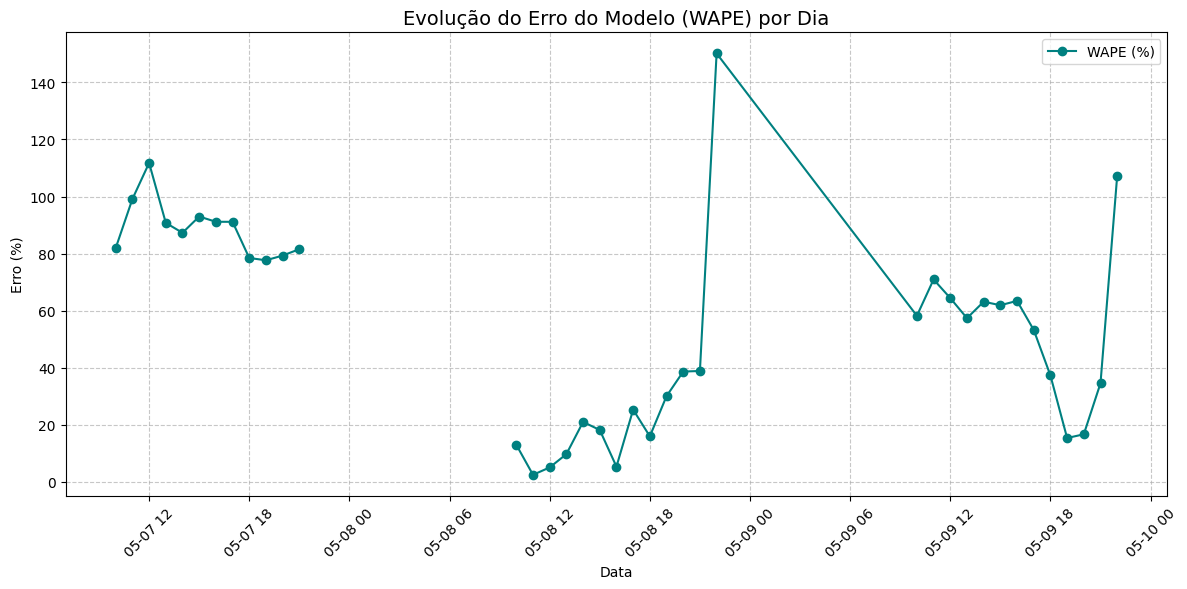

In [27]:
df_fluxo_comparacao_diario = df_fluxo_comparacao.groupby('timestamp_previsao').apply(lambda x: pd.Series({
    'MAE': np.mean(np.abs(x['fluxo'] - x['previsao'])),
    'WAPE': (np.abs(x['fluxo'] - x['previsao']).sum() / x['fluxo'].abs().sum()) * 100
})).reset_index()

plt.figure(figsize=(12, 6))

# Plotando o WAPE para ver a tendência percentual
plt.plot(df_fluxo_comparacao_diario['timestamp_previsao'], df_fluxo_comparacao_diario['WAPE'], marker='o', linestyle='-', color='teal', label='WAPE (%)')

# Adicionando uma linha de tendência (opcional)
plt.title('Evolução do Erro do Modelo (WAPE) por Dia', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Erro (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

In [28]:
df_fluxo_comparacao[df_fluxo_comparacao["timestamp_previsao"].dt.hour == 22]

,fluxo,loja,timestamp_previsao,previsao
598,0,Fluxo,2026-05-07 22:00:00,85.236287
622,2,Fluxo,2026-05-08 22:00:00,-1.003660
646,4,Fluxo,2026-05-09 22:00:00,-0.291367


In [29]:
df_vendas_comparacao = df_vendas_real.merge(
    df_vendas_previsao,
    left_on=['loja', 'timestamp'],
    right_on=['loja', 'timestamp_previsao'],
    how='inner'
)

df_vendas_comparacao = df_vendas_comparacao[(df_vendas_comparacao['timestamp'].dt.hour >= 10) & (df_vendas_comparacao['timestamp'].dt.hour <= 22)]

mae_agrupado_vendas = df_vendas_comparacao.groupby('loja').apply(
    lambda x: np.mean(np.abs(x['fluxo'] - x['previsao']))
)

wape_agrupado_vendas = df_vendas_comparacao.groupby('loja').apply(
    lambda x: (np.abs(x['fluxo'] - x['previsao']).sum() / x['fluxo'].abs().sum()) * 100
)

mae_vendas = np.mean(
    np.abs(df_vendas_comparacao['fluxo'] - df_vendas_comparacao['previsao'])
)

wape_vendas = (
    np.abs(df_vendas_comparacao['fluxo'] - df_vendas_comparacao['previsao']).sum()
    / df_vendas_comparacao['fluxo'].abs().sum()
) * 100

print(f"MAE Vendas: {mae_vendas}")
print(f"WAPE Vendas: {wape_vendas:.2f}%")
print(f"MAE Agrupado Vendas:\n{mae_agrupado_vendas}")
print(f"WAPE Agrupado Vendas:\n{wape_agrupado_vendas}")

MAE Vendas: 13.565398687697412
WAPE Vendas: 84.95%
MAE Agrupado Vendas:
loja
Aramis          22.518146
Arezzo           6.165243
High            15.858899
Ida             28.963574
Off Premium      7.180675
Surto dos 50    19.392406
Vans             7.025570
Vix              1.418677
dtype: float64
WAPE Agrupado Vendas:
loja
Aramis           83.958671
Arezzo           51.267477
High            112.658848
Ida              65.864687
Off Premium      81.646154
Surto dos 50    149.172351
Vans             89.249911
Vix             120.279141
dtype: float64


/tmp/ipykernel_9686/512039193.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  'WAPE': (np.abs(x['fluxo'] - x['previsao']).sum() / x['fluxo'].abs().sum()) * 100


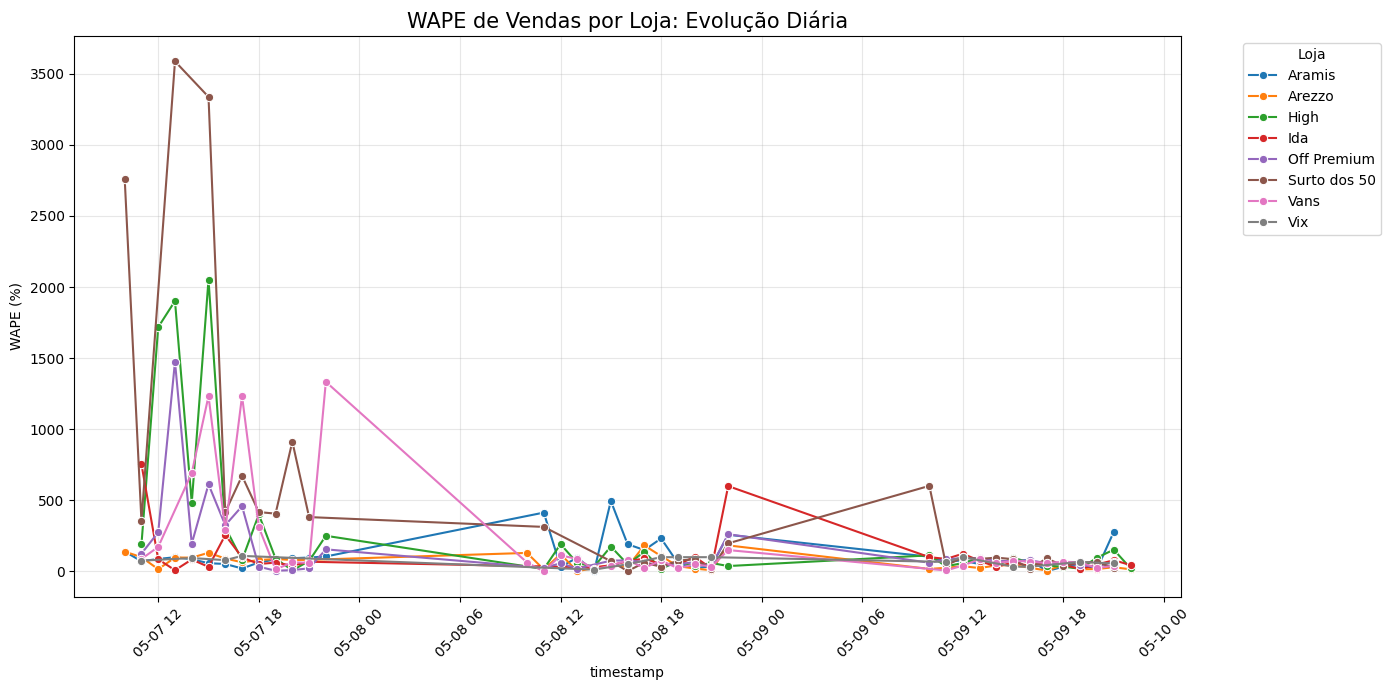

In [30]:
vendas_loja_dia = df_vendas_comparacao.groupby(['timestamp', 'loja']).apply(lambda x: pd.Series({
    'WAPE': (np.abs(x['fluxo'] - x['previsao']).sum() / x['fluxo'].abs().sum()) * 100
})).reset_index()

# Plotar uma linha para cada loja
plt.figure(figsize=(14, 7))
sns.lineplot(data=vendas_loja_dia, x='timestamp', y='WAPE', hue='loja', marker='o')

plt.title('WAPE de Vendas por Loja: Evolução Diária', fontsize=15)
plt.ylabel('WAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend(title='Loja', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

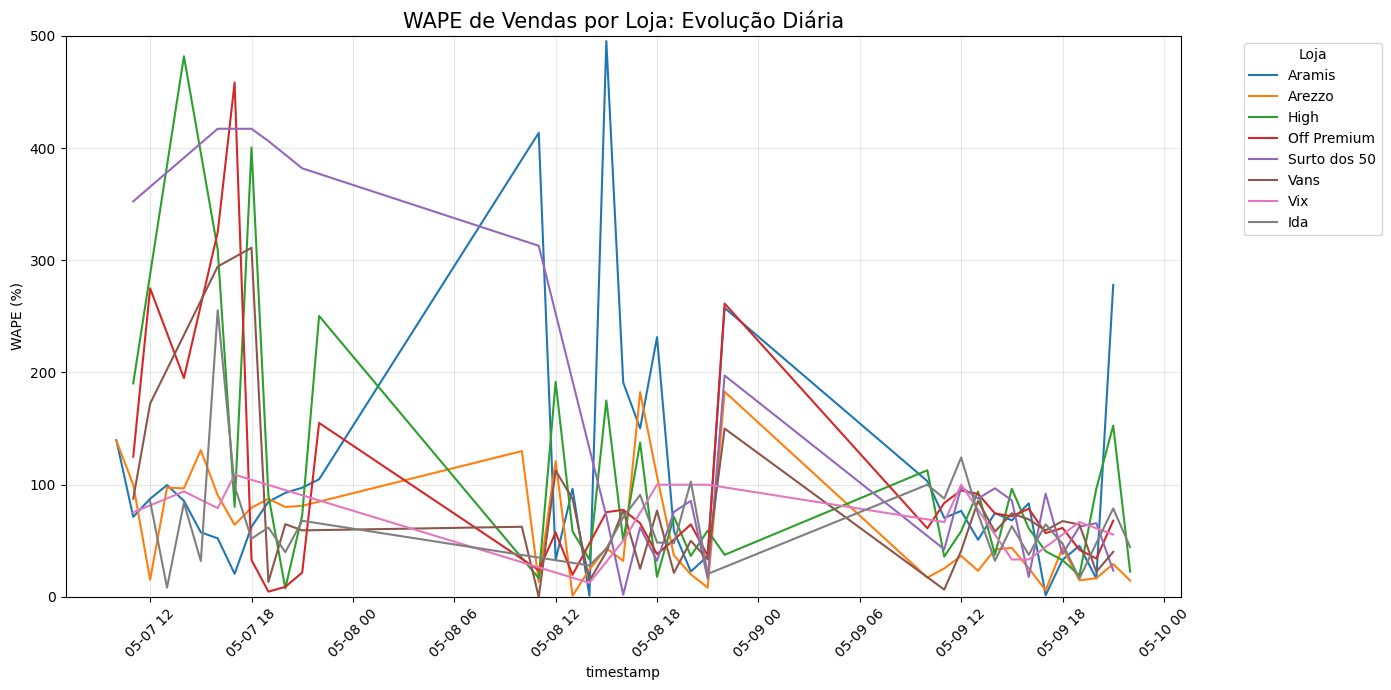

In [31]:
# Gráfico dando um "zoom" na zona de erro aceitável
plt.figure(figsize=(14, 7))
sns.lineplot(data=vendas_loja_dia[vendas_loja_dia['WAPE'] < 500], x='timestamp', y='WAPE', hue='loja')
plt.ylim(0, 500)
plt.title('WAPE de Vendas por Loja: Evolução Diária', fontsize=15)
plt.ylabel('WAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend(title='Loja', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [76]:
# =====================================================================================
# CONFIGURAÇÕES
# =====================================================================================

map_lojas_ticket_medio = {
    "Vans": 200,
    "Arezzo": 180,
    "Off Premium": 320,
    "Ida": 265,
    "Aramis": 452,
    "High": 230,
    "Vix": 480.0,
    "Surto dos 50": 107
}

# =====================================================================================
# FEATURES TEMPORAIS - VENDAS
# =====================================================================================

df_vendas_real['periodo'] = df_vendas_real['timestamp'].dt.hour.map(
    lambda x: 'Antes de 18h' if x < 18 else 'Depois de 18h'
)

df_vendas_real['fim_de_semana'] = (
    df_vendas_real['timestamp'].dt.weekday >= 5
).astype(int)

# =====================================================================================
# VENDAS - SOMENTE DIAS ÚTEIS - ANTES VS DEPOIS DAS 18H
# =====================================================================================

df_vendas_uteis = (
    df_vendas_real[
        df_vendas_real['fim_de_semana'] == 0
    ]
)

tabela_vendas_uteis = (
    df_vendas_uteis
    .groupby(['loja', 'periodo'])['fluxo']
    .sum()
    .unstack()
    .fillna(0)
)

tabela_vendas_uteis['Total'] = (
    tabela_vendas_uteis.sum(axis=1)
)

tabela_vendas_uteis['% Depois de 18h'] = (
    tabela_vendas_uteis['Depois de 18h']
    / tabela_vendas_uteis['Total']
) * 100

tabela_vendas_uteis['Ticket Médio'] = (
    tabela_vendas_uteis.index.map(map_lojas_ticket_medio)
)

tabela_vendas_uteis['Faturamento Antes de 18h'] = (
    tabela_vendas_uteis['Antes de 18h']
    * tabela_vendas_uteis['Ticket Médio']
)

tabela_vendas_uteis['Faturamento Depois de 18h'] = (
    tabela_vendas_uteis['Depois de 18h']
    * tabela_vendas_uteis['Ticket Médio']
)

tabela_vendas_uteis = tabela_vendas_uteis.sort_values(
    '% Depois de 18h',
    ascending=False
)

print("=" * 80)
print("VENDAS - DIAS ÚTEIS - ANTES VS DEPOIS DAS 18H")
print("=" * 80)

print(
    tabela_vendas_uteis[
        [
            'Antes de 18h',
            'Depois de 18h',
            '% Depois de 18h',
            'Faturamento Antes de 18h',
            'Faturamento Depois de 18h'
        ]
    ]
)

media_percentual_depois_18h_uteis = (
    tabela_vendas_uteis['% Depois de 18h']
    .mean()
)

media_percentual_faturamento_uteis = (
    tabela_vendas_uteis['Faturamento Depois de 18h'].sum()
    /
    (
        tabela_vendas_uteis['Faturamento Antes de 18h'].sum()
        + tabela_vendas_uteis['Faturamento Depois de 18h'].sum()
    )
) * 100

print("=" * 80)

print(
    f"Média percentual de vendas depois de 18h "
    f"nos dias úteis: "
    f"{media_percentual_depois_18h_uteis:.2f}%"
)

print(
    f"Média percentual de faturamento depois de 18h "
    f"nos dias úteis: "
    f"{media_percentual_faturamento_uteis:.2f}%"
)

# =====================================================================================
# VENDAS - DIAS ÚTEIS VS FIM DE SEMANA
# =====================================================================================

tabela_fds_vendas = (
    df_vendas_real
    .groupby(['loja', 'fim_de_semana'])['fluxo']
    .sum()
    .unstack()
    .fillna(0)
)

tabela_fds_vendas.columns = [
    'Dia útil',
    'Fim de semana'
]

tabela_fds_vendas['Total'] = (
    tabela_fds_vendas.sum(axis=1)
)

tabela_fds_vendas['%_Fim_de_semana'] = (
    tabela_fds_vendas['Fim de semana']
    / tabela_fds_vendas['Total']
) * 100

tabela_fds_vendas = tabela_fds_vendas.sort_values(
    '%_Fim_de_semana',
    ascending=False
)

print("\n" + "=" * 80)
print("VENDAS - DIAS ÚTEIS VS FIM DE SEMANA")
print("=" * 80)

print(
    tabela_fds_vendas[
        [
            'Dia útil',
            'Fim de semana',
            'Total',
            '%_Fim_de_semana'
        ]
    ]
)

media_percentual_fim_de_semana_vendas = (
    tabela_fds_vendas['%_Fim_de_semana']
    .mean()
)

print("=" * 80)

print(
    f"Média percentual de vendas no fim de semana: "
    f"{media_percentual_fim_de_semana_vendas:.2f}%"
)

# =====================================================================================
# FEATURES TEMPORAIS - FLUXO
# =====================================================================================

df_fluxo_real['periodo'] = df_fluxo_real.index.hour.map(
    lambda x: 'Antes de 18h' if x < 18 else 'Depois de 18h'
)

df_fluxo_real['fim_de_semana'] = (
    df_fluxo_real.index.weekday >= 5
).astype(int)

# =====================================================================================
# FLUXO - DIAS ÚTEIS - ANTES VS DEPOIS DAS 18H
# =====================================================================================

df_fluxo_uteis = (
    df_fluxo_real[
        df_fluxo_real['fim_de_semana'] == 0
    ]
)

tabela_fluxo_uteis = (
    df_fluxo_uteis
    .groupby(['periodo'])['fluxo']
    .sum()
    .to_frame()
    .T
)

tabela_fluxo_uteis['Total'] = (
    tabela_fluxo_uteis.sum(axis=1)
)

tabela_fluxo_uteis['% Depois de 18h'] = (
    tabela_fluxo_uteis['Depois de 18h']
    / tabela_fluxo_uteis['Total']
) * 100

print("\n" + "=" * 80)
print("FLUXO - DIAS ÚTEIS - ANTES VS DEPOIS DAS 18H")
print("=" * 80)

print(
    tabela_fluxo_uteis[
        [
            'Antes de 18h',
            'Depois de 18h',
            'Total',
            '% Depois de 18h'
        ]
    ]
)

print("=" * 80)

print(
    f"Percentual de fluxo depois de 18h "
    f"nos dias úteis: "
    f"{tabela_fluxo_uteis['% Depois de 18h'].iloc[0]:.2f}%"
)

# =====================================================================================
# FLUXO - DIAS ÚTEIS VS FIM DE SEMANA
# =====================================================================================

tabela_fluxo_fds = (
    df_fluxo_real
    .groupby(['fim_de_semana'])['fluxo']
    .sum()
    .to_frame()
    .T
)

tabela_fluxo_fds.columns = [
    'Dia útil',
    'Fim de semana'
]

tabela_fluxo_fds['Total'] = (
    tabela_fluxo_fds.sum(axis=1)
)

tabela_fluxo_fds['%_Fim_de_semana'] = (
    tabela_fluxo_fds['Fim de semana']
    / tabela_fluxo_fds['Total']
) * 100

print("\n" + "=" * 80)
print("FLUXO - DIAS ÚTEIS VS FIM DE SEMANA")
print("=" * 80)

print(
    tabela_fluxo_fds[
        [
            'Dia útil',
            'Fim de semana',
            'Total',
            '%_Fim_de_semana'
        ]
    ]
)

print("=" * 80)

print(
    f"Percentual de fluxo no fim de semana: "
    f"{tabela_fluxo_fds['%_Fim_de_semana'].iloc[0]:.2f}%"
)

VENDAS - DIAS ÚTEIS - ANTES VS DEPOIS DAS 18H
periodo       Antes de 18h  Depois de 18h  % Depois de 18h  \
loja                                                         
Aramis               195.0          477.0        70.982143   
High                 108.0          216.0        66.666667   
Off Premium           80.0          124.0        60.784314   
Surto dos 50          53.0           74.0        58.267717   
Vans                  59.0           76.0        56.296296   
Ida                  455.0          401.0        46.845794   
Arezzo               153.0          126.0        45.161290   
Vix                   21.0            8.0        27.586207   

periodo       Faturamento Antes de 18h  Faturamento Depois de 18h  
loja                                                               
Aramis                         88140.0                   215604.0  
High                           24840.0                    49680.0  
Off Premium                    25600.0                    396